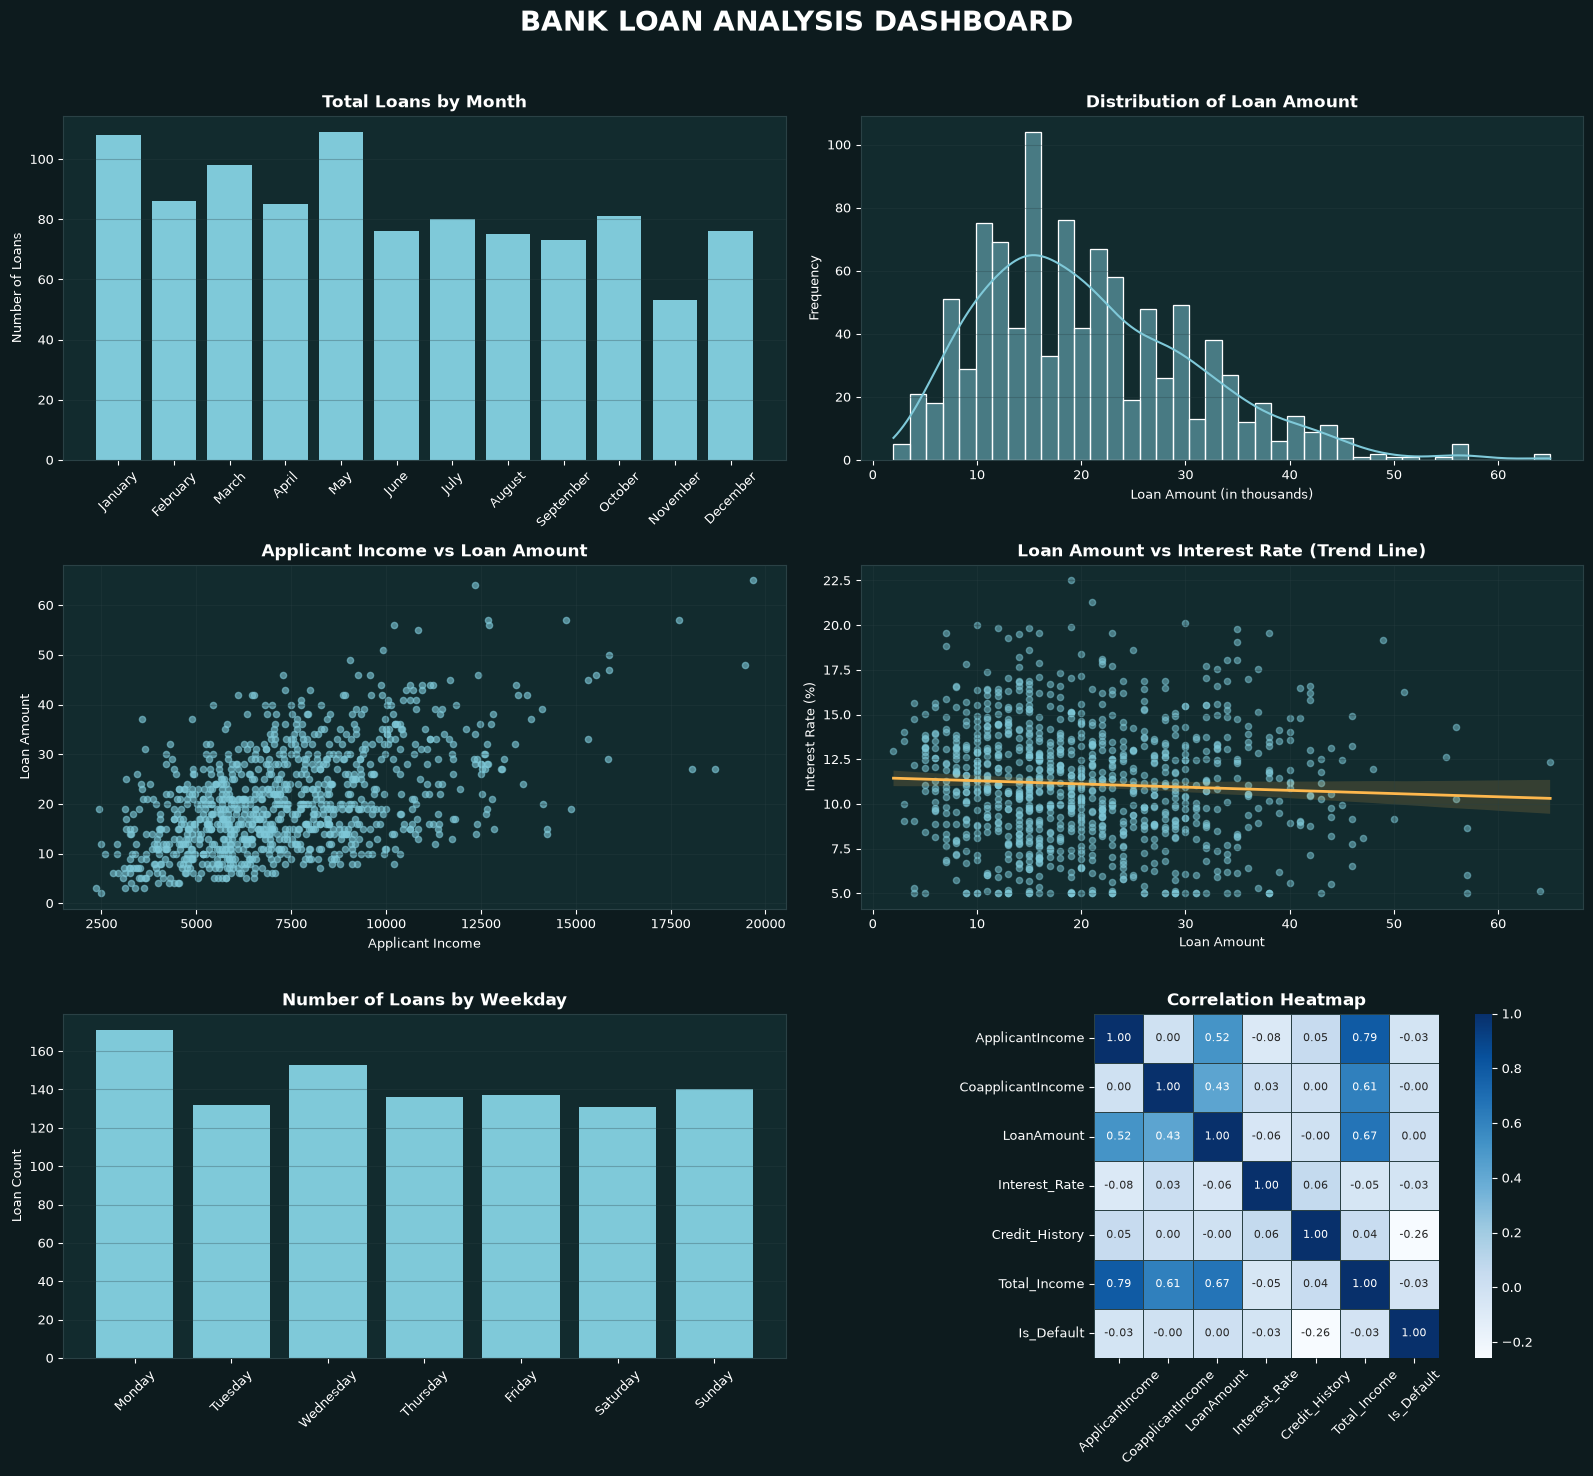


Dashboard saved as 'bank_loan_dashboard.png'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\excel project\bank_loan_dataset_cleaned.csv")
df["Application_Date"] = pd.to_datetime(df["Application_Date"], errors="coerce")

#   THEME  
plt.style.use("dark_background")

BG_COLOR = "#0d1b1e"        # overall figure background
PANEL_COLOR = "#122b2e"     # chart panel background (teal-dark)
BAR_COLOR = "#7fc9d9"       # light blue bars
LINE_COLOR = "#7fc9d9"      # trend line color
GRID_COLOR = "#2a4145"      # subtle gridlines
HEATMAP_CMAP = "Blues"

plt.rcParams["figure.facecolor"] = BG_COLOR
plt.rcParams["axes.facecolor"] = PANEL_COLOR
plt.rcParams["axes.edgecolor"] = GRID_COLOR
plt.rcParams["grid.color"] = GRID_COLOR
plt.rcParams["text.color"] = "white"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["xtick.color"] = "white"
plt.rcParams["ytick.color"] = "white"
plt.rcParams["font.size"] = 9

#  CREATE 3x2 DASHBOARD GRID
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.suptitle("BANK LOAN ANALYSIS DASHBOARD", fontsize=20, fontweight="bold", color="white", y=0.98)

#  Panel 1: Total Loans by Month 
monthly = df.dropna(subset=["Application_Date"]).copy()
monthly["month_name"] = monthly["Application_Date"].dt.month_name()
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
monthly_counts = monthly["month_name"].value_counts().reindex(month_order)

axes[0, 0].bar(monthly_counts.index, monthly_counts.values, color=BAR_COLOR)
axes[0, 0].set_title("Total Loans by Month", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Number of Loans")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(axis="y", alpha=0.3)

# Panel 2: Distribution of Loan Amount 
sns.histplot(df["LoanAmount"], bins=40, kde=True, color=BAR_COLOR, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Loan Amount", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Loan Amount (in thousands)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].grid(axis="y", alpha=0.3)

# Panel 3: Applicant Income vs Loan Amount 
axes[1, 0].scatter(df["ApplicantIncome"], df["LoanAmount"], color=BAR_COLOR, alpha=0.6, s=20)
axes[1, 0].set_title("Applicant Income vs Loan Amount", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Applicant Income")
axes[1, 0].set_ylabel("Loan Amount")
axes[1, 0].grid(alpha=0.3)

# Panel 4: Loan Amount vs Interest Rate (with trend line) 
sns.regplot(
    data=df, x="LoanAmount", y="Interest_Rate",
    scatter_kws={"color": BAR_COLOR, "alpha": 0.5, "s": 20},
    line_kws={"color": "#ffb84d", "linewidth": 2},
    ax=axes[1, 1]
)
axes[1, 1].set_title("Loan Amount vs Interest Rate (Trend Line)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Loan Amount")
axes[1, 1].set_ylabel("Interest Rate (%)")
axes[1, 1].grid(alpha=0.3)

# Panel 5: Number of Loans by Weekday 
weekday_df = df.dropna(subset=["Application_Date"]).copy()
weekday_df["weekday"] = weekday_df["Application_Date"].dt.day_name()
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_counts = weekday_df["weekday"].value_counts().reindex(weekday_order)

axes[2, 0].bar(weekday_counts.index, weekday_counts.values, color=BAR_COLOR)
axes[2, 0].set_title("Number of Loans by Weekday", fontsize=12, fontweight="bold")
axes[2, 0].set_ylabel("Loan Count")
axes[2, 0].tick_params(axis="x", rotation=45)
axes[2, 0].grid(axis="y", alpha=0.3)

# Panel 6: Correlation Heatmap 
numeric_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount",
                "Interest_Rate", "Credit_History", "Total_Income", "Is_Default"]
corr = df[numeric_cols].corr()

sns.heatmap(
    corr, annot=True, fmt=".2f", cmap=HEATMAP_CMAP, square=True,
    cbar=True, ax=axes[2, 1], annot_kws={"size": 8},
    linewidths=0.5, linecolor=GRID_COLOR
)
axes[2, 1].set_title("Correlation Heatmap", fontsize=12, fontweight="bold")
axes[2, 1].tick_params(axis="x", rotation=45)
axes[2, 1].tick_params(axis="y", rotation=0)

#  FINAL LAYOUT & SAVE
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("bank_loan_dashboard.png", dpi=200, facecolor=BG_COLOR)
plt.show()
print("\nDashboard saved as 'bank_loan_dashboard.png'")